# SoccerTwos Training Curves

Run this after syncing `ray_results/` and `eval_results/` from PACE/local evaluation. The key distinction is that RLlib `episode_reward_mean` is a training signal, not the grading metric. Use it to understand learning dynamics, then use CEIA win rate and goal differential to select submissions.

In [19]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", "report_plots/.matplotlib")

import matplotlib.pyplot as plt
import pandas as pd

RAY_RESULTS = Path("ray_results")
EVAL_RESULTS = Path("eval_results")
OUT_DIR = Path("report_plots")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SMOOTH_WINDOW = 5

In [20]:
EXPERIMENT_DIRS = {
    "Baseline": "PPO_selfplay_baseline",
    "Reward Shaping": "PPO_selfplay_shaped",
    "Self-Play Archive": "PPO_selfplay_rec",
    "Curriculum": "PPO_curriculum_multiagent",
    "Curriculum V4": "PPO_curriculum_multiagent_V4_aggressive_combo",
    "Shared V5": "PPO_curriculum_shared_V5_dynamic_aggressive",
}

COLORS = {
    "Baseline": "#5b6472",
    "Reward Shaping": "#0f8b8d",
    "Self-Play Archive": "#7b2cbf",
    "Curriculum": "#c2410c",
    "Curriculum V4": "#dc2626",
    "Shared V5": "#2563eb",
}

progress_rows = []
for family, dirname in EXPERIMENT_DIRS.items():
    for p in sorted((RAY_RESULTS / dirname).glob("*/progress.csv")):
        progress_rows.append({"family": family, "run_id": p.parent.name, "path": p})

pd.DataFrame(progress_rows)

,family,run_id,path
0,Baseline,PPO_Soccer_65438_00000_0_2026-04-21_17-59-40,ray_results/PPO_selfplay_baseline/PPO_Soccer_6...
1,Baseline,PPO_Soccer_a9da3_00000_0_2026-04-21_13-51-03,ray_results/PPO_selfplay_baseline/PPO_Soccer_a...
2,Baseline,PPO_Soccer_cf10c_00000_0_2026-04-21_15-10-49,ray_results/PPO_selfplay_baseline/PPO_Soccer_c...
3,Baseline,PPO_Soccer_cf7c0_00000_0_2026-04-21_14-49-22,ray_results/PPO_selfplay_baseline/PPO_Soccer_c...
4,Baseline,PPO_Soccer_e6436_00000_0_2026-04-21_14-50-00,ray_results/PPO_selfplay_baseline/PPO_Soccer_e...
5,Reward Shaping,PPO_Soccer_301b1_00000_0_2026-04-21_14-59-14,ray_results/PPO_selfplay_shaped/PPO_Soccer_301...
6,Reward Shaping,PPO_Soccer_67e14_00000_0_2026-04-21_14-53-37,ray_results/PPO_selfplay_shaped/PPO_Soccer_67e...
7,Reward Shaping,PPO_Soccer_a6de6_00000_0_2026-04-21_13-58-07,ray_results/PPO_selfplay_shaped/PPO_Soccer_a6d...
8,Reward Shaping,PPO_Soccer_a9da3_00000_0_2026-04-21_13-51-03,ray_results/PPO_selfplay_shaped/PPO_Soccer_a9d...
9,Reward Shaping,PPO_Soccer_d5022_00000_0_2026-04-21_18-24-16,ray_results/PPO_selfplay_shaped/PPO_Soccer_d50...


In [21]:
runs = []
summary_rows = []

for row in progress_rows:
    try:
        df = pd.read_csv(row["path"])
    except pd.errors.EmptyDataError:
        continue
    if df.empty or "episode_reward_mean" not in df:
        continue

    family = row["family"]
    run_id = row["run_id"]
    runs.append({**row, "df": df})

    last = df.iloc[-1]
    best = df.loc[df["episode_reward_mean"].idxmax()]
    summary_rows.append({
        "family": family,
        "run_id": run_id,
        "training_iteration": last.get("training_iteration"),
        "timesteps_total": last.get("timesteps_total"),
        "time_total_h": last.get("time_total_s") / 3600.0,
        "final_reward_mean": last.get("episode_reward_mean"),
        "final_reward_min": last.get("episode_reward_min"),
        "final_reward_max": last.get("episode_reward_max"),
        "best_reward_mean": best.get("episode_reward_mean"),
        "best_reward_iteration": best.get("training_iteration"),
        "best_reward_timestep": best.get("timesteps_total"),
        "path": str(row["path"]),
    })

training_summary = pd.DataFrame(summary_rows).sort_values(
    ["family", "time_total_h"], ascending=[True, False]
)
training_summary.to_csv(OUT_DIR / "training_summary.csv", index=False)
training_summary

,family,run_id,training_iteration,timesteps_total,time_total_h,final_reward_mean,final_reward_min,final_reward_max,best_reward_mean,best_reward_iteration,best_reward_timestep,path
0,Baseline,PPO_Soccer_65438_00000_0_2026-04-21_17-59-40,585,4170121,8.007104,-0.279868,-1.622800,0.000000,-0.191024,559,4024399,ray_results/PPO_selfplay_baseline/PPO_Soccer_6...
1,Baseline,PPO_Soccer_a9da3_00000_0_2026-04-21_13-51-03,50,389995,0.613363,-0.327444,-1.915200,0.000000,-0.233884,43,334104,ray_results/PPO_selfplay_baseline/PPO_Soccer_a...
2,Baseline,PPO_Soccer_e6436_00000_0_2026-04-21_14-50-00,3,23542,0.035426,-0.302760,-1.886800,0.000000,-0.302760,3,23542,ray_results/PPO_selfplay_baseline/PPO_Soccer_e...
12,Curriculum,PPO_Soccer_6efa0_00000_0_2026-04-21_17-24-09,646,4771383,8.003590,1.743383,-0.483470,6.820670,2.436290,173,1322017,ray_results/PPO_curriculum_multiagent/PPO_Socc...
13,Curriculum V4,PPO_Soccer_4a880_00000_0_2026-04-22_00-32-38,127,888215,1.512160,1.848693,-0.377803,8.595461,2.263088,101,719914,ray_results/PPO_curriculum_multiagent_V4_aggre...
6,Reward Shaping,PPO_Soccer_d5022_00000_0_2026-04-21_18-24-16,870,5064375,8.000035,0.199292,-0.122973,0.930405,1.642880,72,554815,ray_results/PPO_selfplay_shaped/PPO_Soccer_d50...
7,Reward Shaping,PPO_Soccer_dbb5e_00000_0_2026-04-21_15-11-11,137,1067834,1.577287,-2.551704,-5.933200,-0.095200,-2.384316,111,870022,ray_results/PPO_selfplay_shaped/PPO_Soccer_dbb...
5,Reward Shaping,PPO_Soccer_a6de6_00000_0_2026-04-21_13-58-07,42,330824,0.547030,-3.430525,-5.796665,0.050712,-3.227486,34,265533,ray_results/PPO_selfplay_shaped/PPO_Soccer_a6d...
3,Reward Shaping,PPO_Soccer_301b1_00000_0_2026-04-21_14-59-14,2,16425,0.025587,-3.528231,-4.780598,-0.180227,-3.378002,1,8272,ray_results/PPO_selfplay_shaped/PPO_Soccer_301...
4,Reward Shaping,PPO_Soccer_67e14_00000_0_2026-04-21_14-53-37,2,13917,0.024695,-3.078059,-5.653670,-0.292648,-2.671151,1,7008,ray_results/PPO_selfplay_shaped/PPO_Soccer_67e...


In [22]:
# Pick the longest usable run from each experiment family for the clean report plot.
main_runs = []
for family in EXPERIMENT_DIRS:
    family_runs = [r for r in runs if r["family"] == family]
    if not family_runs:
        continue
    main_runs.append(max(family_runs, key=lambda r: r["df"].iloc[-1].get("time_total_s", 0.0)))

[(r["family"], r["run_id"], r["df"].iloc[-1].get("time_total_s", 0.0) / 3600.0) for r in main_runs]

[('Baseline',
  'PPO_Soccer_65438_00000_0_2026-04-21_17-59-40',
  8.00710361096594),
 ('Reward Shaping',
  'PPO_Soccer_d5022_00000_0_2026-04-21_18-24-16',
  8.000035369859802),
 ('Self-Play Archive',
  'PPO_Soccer_32674_00000_0_2026-04-21_19-24-09',
  8.00496728334162),
 ('Curriculum',
  'PPO_Soccer_6efa0_00000_0_2026-04-21_17-24-09',
  8.003589655028449),
 ('Curriculum V4',
  'PPO_Soccer_4a880_00000_0_2026-04-22_00-32-38',
  1.512160466313362),
 ('Shared V5',
  'PPO_Soccer_9fc34_00000_0_2026-04-22_01-10-48',
  1.5009484314918518)]

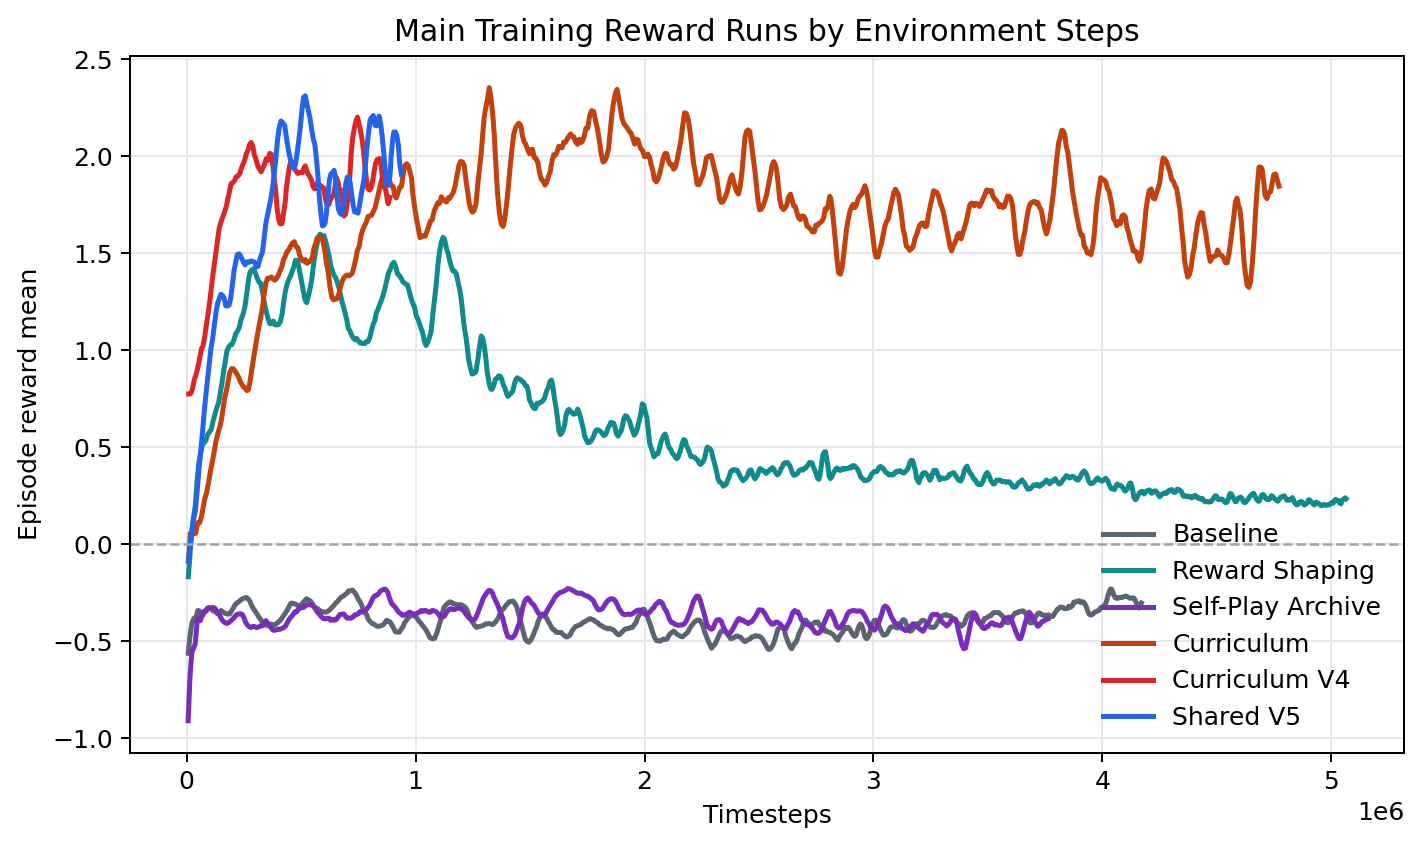

In [23]:
fig, ax = plt.subplots(figsize=(8, 4.8), dpi=180)
for run in main_runs:
    df = run["df"]
    family = run["family"]
    x = df["timesteps_total"] if "timesteps_total" in df else df.index
    y = df["episode_reward_mean"].rolling(SMOOTH_WINDOW, min_periods=1).mean()
    ax.plot(x, y, label=family, linewidth=2.0, color=COLORS.get(family))

ax.axhline(0, color="#9ca3af", linewidth=1, linestyle="--")
ax.set_title("Main Training Reward Runs by Environment Steps")
ax.set_xlabel("Timesteps")
ax.set_ylabel("Episode reward mean")
ax.grid(True, color="#e5e7eb", linewidth=0.8)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT_DIR / "reward_vs_timesteps.png")
plt.show()

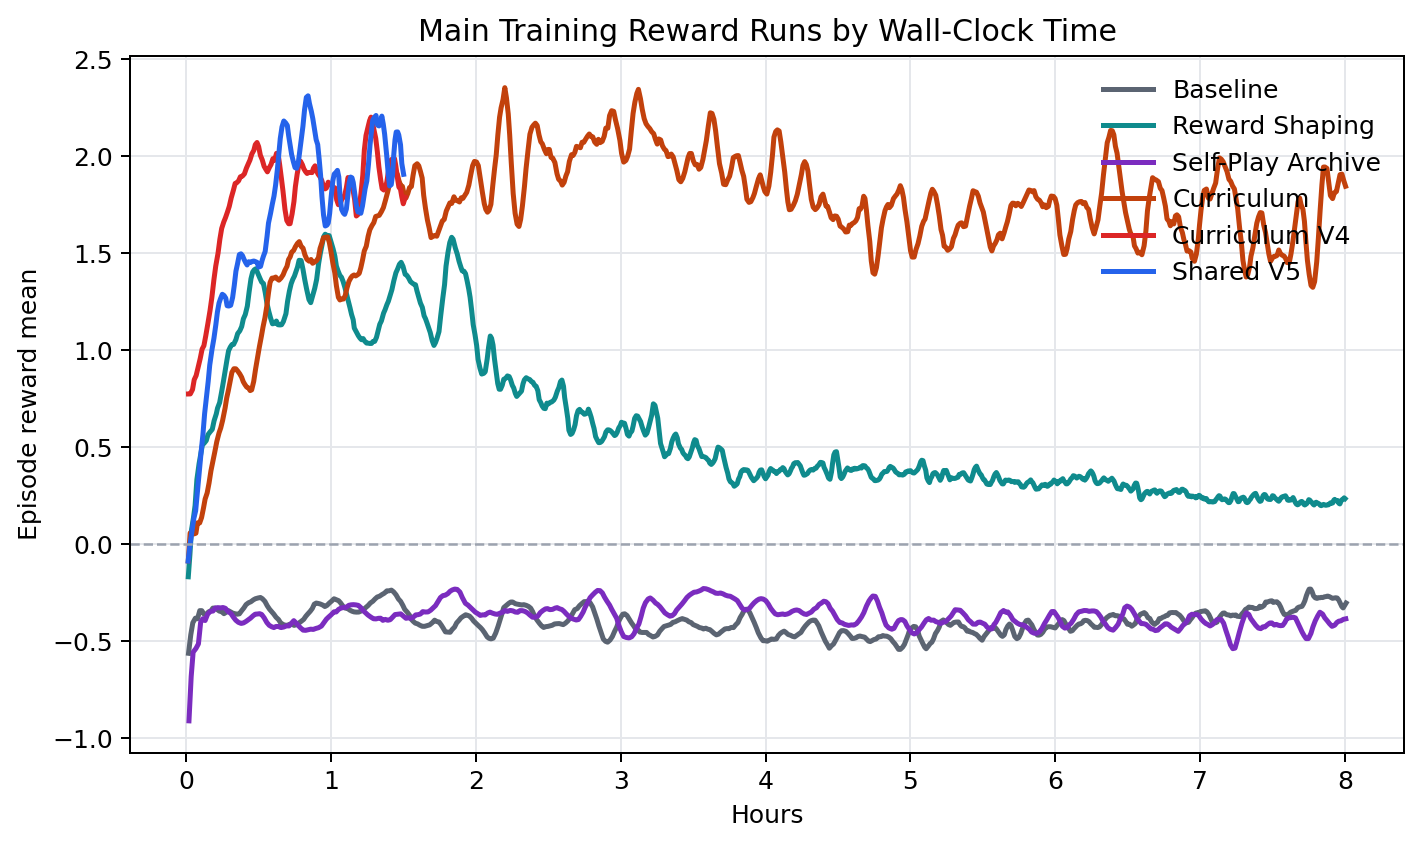

In [24]:
fig, ax = plt.subplots(figsize=(8, 4.8), dpi=180)
for run in main_runs:
    df = run["df"]
    if "time_total_s" not in df:
        continue
    family = run["family"]
    x = df["time_total_s"] / 3600.0
    y = df["episode_reward_mean"].rolling(SMOOTH_WINDOW, min_periods=1).mean()
    ax.plot(x, y, label=family, linewidth=2.0, color=COLORS.get(family))

ax.axhline(0, color="#9ca3af", linewidth=1, linestyle="--")
ax.set_title("Main Training Reward Runs by Wall-Clock Time")
ax.set_xlabel("Hours")
ax.set_ylabel("Episode reward mean")
ax.grid(True, color="#e5e7eb", linewidth=0.8)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT_DIR / "reward_vs_time.png")
plt.show()

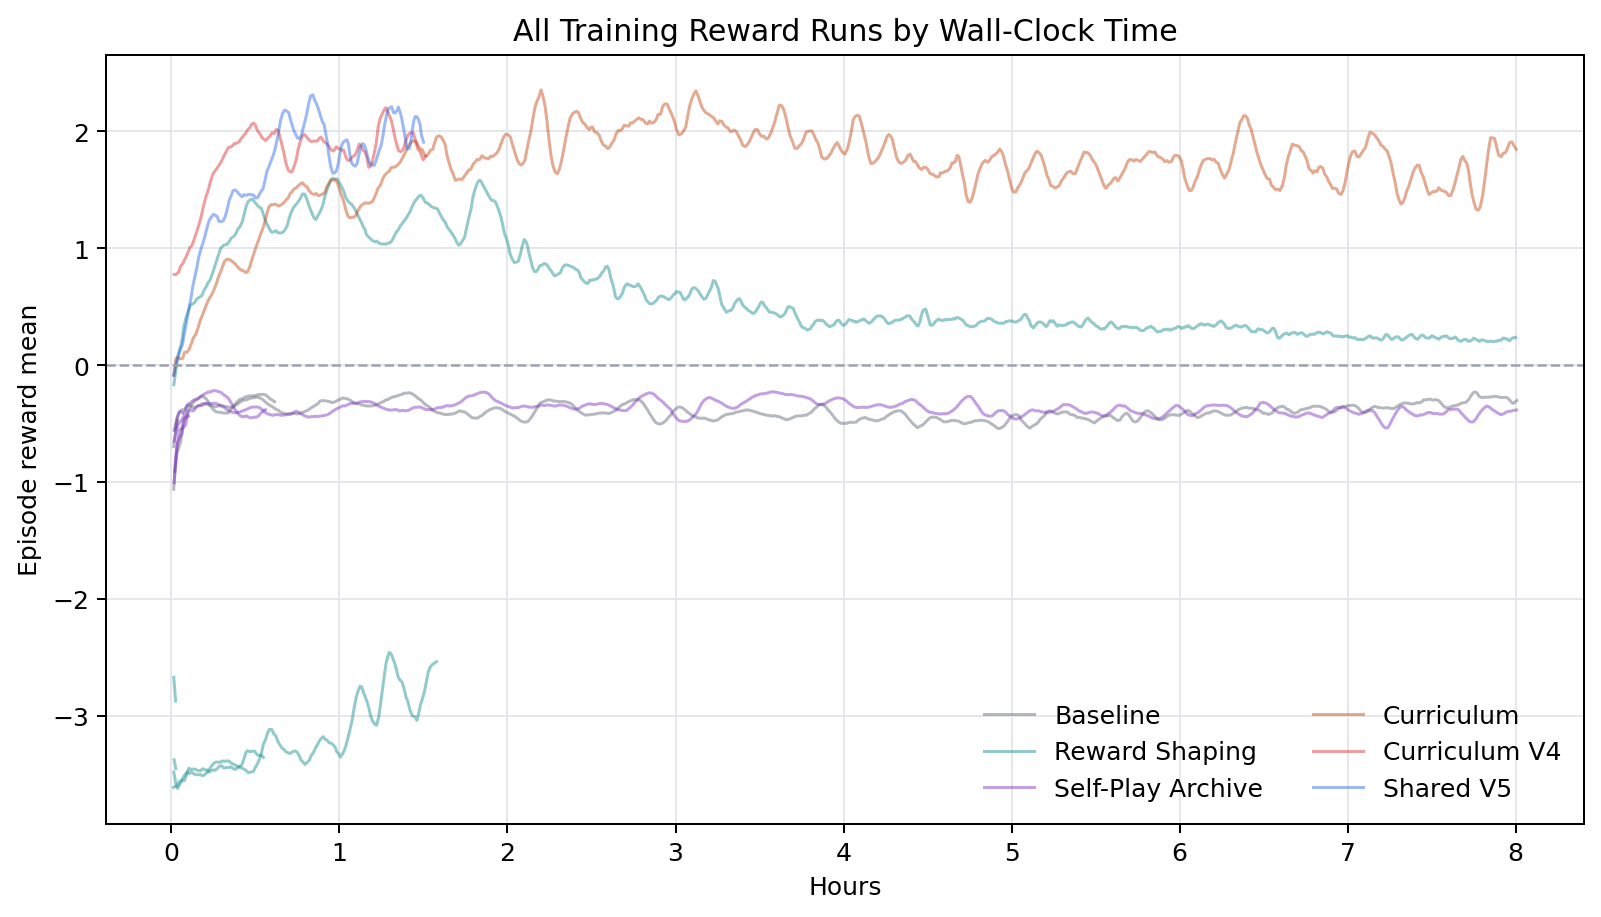

In [25]:
fig, ax = plt.subplots(figsize=(9, 5.2), dpi=180)
seen = set()
for run in runs:
    df = run["df"]
    if "time_total_s" not in df:
        continue
    family = run["family"]
    x = df["time_total_s"] / 3600.0
    y = df["episode_reward_mean"].rolling(SMOOTH_WINDOW, min_periods=1).mean()
    ax.plot(
        x,
        y,
        label=family if family not in seen else None,
        linewidth=1.2,
        alpha=0.45,
        color=COLORS.get(family),
    )
    seen.add(family)

ax.axhline(0, color="#9ca3af", linewidth=1, linestyle="--")
ax.set_title("All Training Reward Runs by Wall-Clock Time")
ax.set_xlabel("Hours")
ax.set_ylabel("Episode reward mean")
ax.grid(True, color="#e5e7eb", linewidth=0.8)
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
fig.savefig(OUT_DIR / "all_reward_vs_time.png")
plt.show()

## Submission Evaluation

These are game outcomes, so they should be used for submission selection. Training reward can be negative while a submission beats random because reward shaping, self-play opponents, episode length, and sparse scoring do not map cleanly to the external evaluator. CEIA `0/25` ties are especially misleading, so goal differential is a better secondary signal.

In [26]:
submission_eval = pd.DataFrame([
    {"agent": "TEAM4_AGENT_REWARD", "vs_ceia_wins_out_of_25": 0, "ceia_goal_diff_sample": -63, "vs_random_score_out_of_25": 25.000},
    {"agent": "TEAM4_AGENT_SELFPLAY", "vs_ceia_wins_out_of_25": 0, "ceia_goal_diff_sample": -113, "vs_random_score_out_of_25": 22.222},
    {"agent": "TEAM4_AGENT_CURRICULUM_V5", "vs_ceia_wins_out_of_25": 0, "ceia_goal_diff_sample": -144, "vs_random_score_out_of_25": 13.889},
    {"agent": "TEAM4_AGENT_SELFPLAY_REC", "vs_ceia_wins_out_of_25": 0, "ceia_goal_diff_sample": -160, "vs_random_score_out_of_25": 25.000},
    {"agent": "TEAM4_AGENT_CURRICULUM", "vs_ceia_wins_out_of_25": 0, "ceia_goal_diff_sample": -162, "vs_random_score_out_of_25": 25.000},
    {"agent": "TEAM4_AGENT_CURRICULUM_V4", "vs_ceia_wins_out_of_25": 0, "ceia_goal_diff_sample": -171, "vs_random_score_out_of_25": 22.222},
])
submission_eval["rank_by_ceia_goal_diff"] = submission_eval["ceia_goal_diff_sample"].rank(
    ascending=False, method="min"
).astype(int)
submission_eval = submission_eval.sort_values(
    ["vs_ceia_wins_out_of_25", "ceia_goal_diff_sample"], ascending=False
)
submission_eval.to_csv(OUT_DIR / "submission_eval_summary.csv", index=False)
submission_eval

,agent,vs_ceia_wins_out_of_25,ceia_goal_diff_sample,vs_random_score_out_of_25,rank_by_ceia_goal_diff
0,TEAM4_AGENT_REWARD,0,-63,25.000,1
1,TEAM4_AGENT_SELFPLAY,0,-113,22.222,2
2,TEAM4_AGENT_CURRICULUM_V5,0,-144,13.889,3
3,TEAM4_AGENT_SELFPLAY_REC,0,-160,25.000,4
4,TEAM4_AGENT_CURRICULUM,0,-162,25.000,5
5,TEAM4_AGENT_CURRICULUM_V4,0,-171,22.222,6


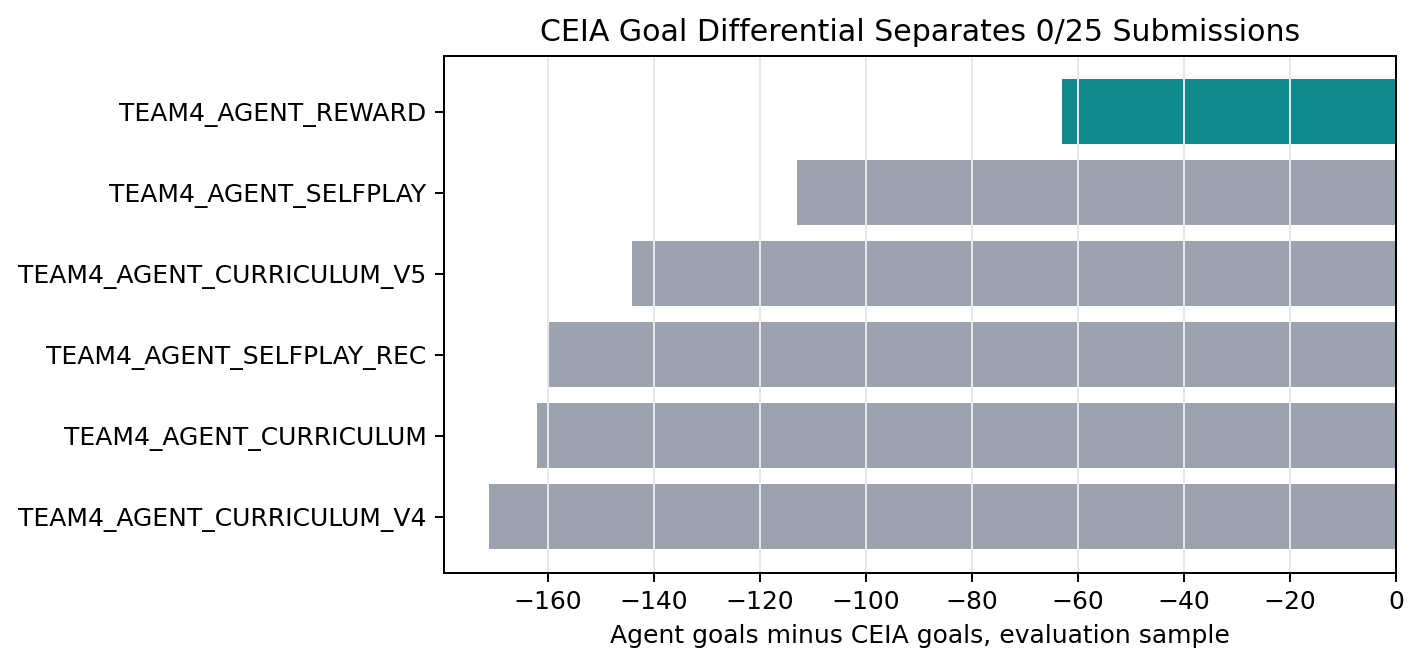

In [27]:
fig, ax = plt.subplots(figsize=(8, 3.8), dpi=180)
plot_df = submission_eval.sort_values("ceia_goal_diff_sample")
bar_colors = ["#0f8b8d" if a == "TEAM4_AGENT_REWARD" else "#9ca3af" for a in plot_df["agent"]]
ax.barh(plot_df["agent"], plot_df["ceia_goal_diff_sample"], color=bar_colors)
ax.axvline(0, color="#111827", linewidth=1)
ax.set_title("CEIA Goal Differential Separates 0/25 Submissions")
ax.set_xlabel("Agent goals minus CEIA goals, evaluation sample")
ax.grid(True, axis="x", color="#e5e7eb", linewidth=0.8)
fig.tight_layout()
fig.savefig(OUT_DIR / "submission_ceia_goal_diff.png")
plt.show()

In [28]:
# Checkpoint sweep against CEIA for TEAM4_AGENT_REWARD.
checkpoint_rows = []
for path in sorted(EVAL_RESULTS.glob("reward_checkpoint_*_vs_ceia.csv")):
    df = pd.read_csv(path)
    games = len(df)
    checkpoint = path.stem.replace("reward_", "").replace("_vs_ceia", "")
    checkpoint_rows.append({
        "checkpoint": checkpoint,
        "games": games,
        "agent_wins": int((df["result"] == "a_win").sum()),
        "ceia_wins": int((df["result"] == "b_win").sum()),
        "draws": int((df["result"] == "draw").sum()),
        "win_rate": float((df["result"] == "a_win").mean()) if games else 0.0,
        "mean_reward_margin": float((df["a_reward"] - df["b_reward"]).mean()) if games else 0.0,
    })

checkpoint_eval = pd.DataFrame(checkpoint_rows).sort_values("win_rate", ascending=False)
checkpoint_eval.to_csv(OUT_DIR / "reward_checkpoint_eval_summary.csv", index=False)
checkpoint_eval

,checkpoint,games,agent_wins,ceia_wins,draws,win_rate,mean_reward_margin
6,checkpoint_000700,20,10,10,0,0.50,-0.02862
8,checkpoint_000870,20,7,13,0,0.35,-1.20664
3,checkpoint_000400,20,3,17,0,0.15,-2.62364
4,checkpoint_000500,20,3,17,0,0.15,-2.70670
5,checkpoint_000600,20,3,17,0,0.15,-2.67712
7,checkpoint_000800,20,3,17,0,0.15,-2.73596
2,checkpoint_000300,20,2,18,0,0.10,-3.11018
0,checkpoint_000100,20,1,19,0,0.05,-3.47712
1,checkpoint_000200,20,0,20,0,0.00,-3.83924


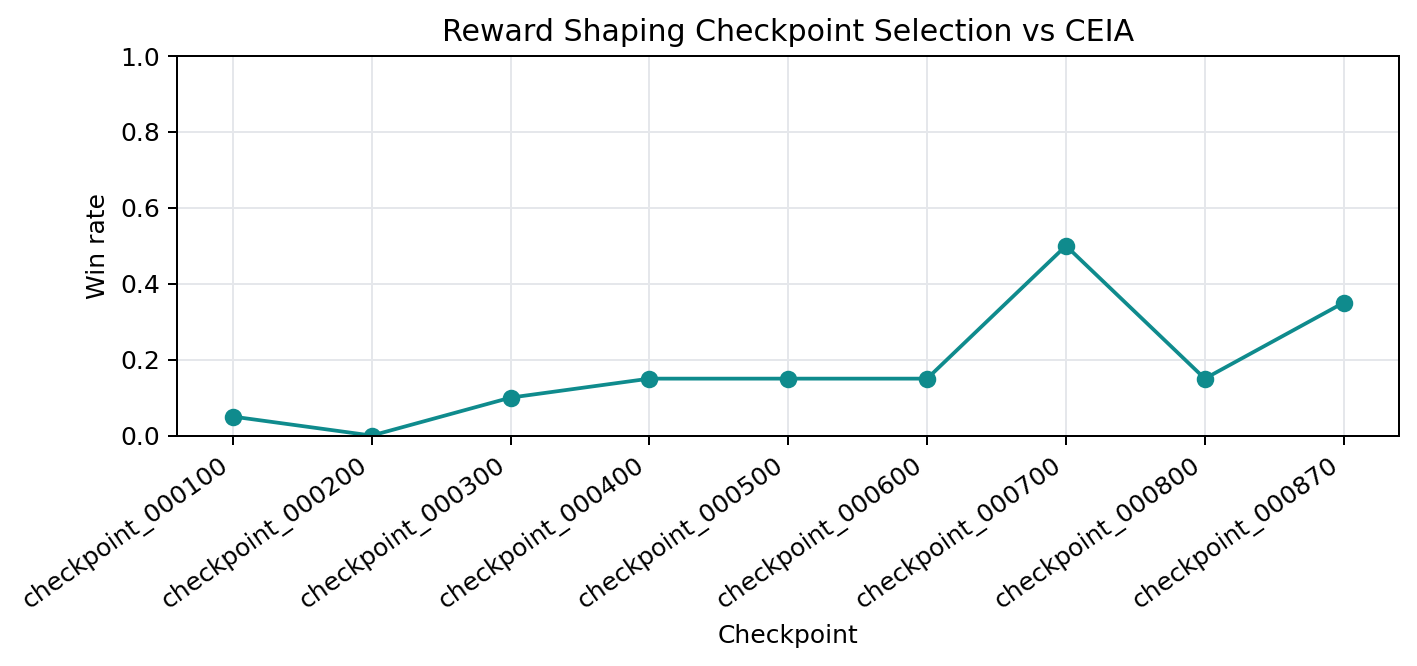

In [29]:
if not checkpoint_eval.empty:
    fig, ax = plt.subplots(figsize=(8, 3.8), dpi=180)
    ordered = checkpoint_eval.sort_values("checkpoint")
    ax.plot(ordered["checkpoint"], ordered["win_rate"], marker="o", color="#0f8b8d")
    ax.set_title("Reward Shaping Checkpoint Selection vs CEIA")
    ax.set_xlabel("Checkpoint")
    ax.set_ylabel("Win rate")
    ax.set_ylim(0, 1)
    ax.grid(True, color="#e5e7eb", linewidth=0.8)
    plt.xticks(rotation=35, ha="right")
    fig.tight_layout()
    fig.savefig(OUT_DIR / "reward_checkpoint_win_rate.png")
    plt.show()

In [30]:
print("Wrote:")
for p in [
    OUT_DIR / "training_summary.csv",
    OUT_DIR / "submission_eval_summary.csv",
    OUT_DIR / "reward_checkpoint_eval_summary.csv",
    OUT_DIR / "reward_vs_timesteps.png",
    OUT_DIR / "reward_vs_time.png",
    OUT_DIR / "all_reward_vs_time.png",
    OUT_DIR / "submission_ceia_goal_diff.png",
    OUT_DIR / "reward_checkpoint_win_rate.png",
]:
    if p.exists():
        print(p)

Wrote:
report_plots/training_summary.csv
report_plots/submission_eval_summary.csv
report_plots/reward_checkpoint_eval_summary.csv
report_plots/reward_vs_timesteps.png
report_plots/reward_vs_time.png
report_plots/all_reward_vs_time.png
report_plots/submission_ceia_goal_diff.png
report_plots/reward_checkpoint_win_rate.png
